In [281]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import time
import math
import numpy as np
import matplotlib.pyplot as plt

import keras
from keras import layers

from keras.utils import to_categorical

from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


In [282]:
print("Keras version:", keras.__version__)
print("Backend:", keras.backend.backend())

Keras version: 3.13.2
Backend: tensorflow


In [283]:
# Model / data parameters
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

num_classes = 10
input_shape = (32, 32, 3)

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

/home/valvoja/miniconda3/envs/keras/lib/python3.11/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [284]:
# Normalizing
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

#One hot encoding
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)
y_true = np.argmax(y_test, axis=1) # For later use in evaluation

In [285]:
augmenter = keras.Sequential([
    layers.RandomFlip("horizontal"),
#    layers.RandomTranslation(0.1, 0.1),
    layers.RandomRotation(0.03),
    layers.RandomZoom(0.08),
], name="data_augmentation")

augmenter


<Sequential name=data_augmentation, built=False>

## CNN model

This model includes:
- multiple convolution blocks
- batch normalization
- max pooling
- dropout
- a dense classifier head


In [286]:
inputs = keras.Input(shape=input_shape)

x = augmenter(inputs)

# Convolutional block 1
x = layers.Conv2D(32, (3, 3), padding="same", activation=None, use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Conv2D(32, (3, 3), padding="same", activation=None, use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)
x = layers.Dropout(0.20)(x)

# Convolutional block 2
x = layers.Conv2D(64, (3, 3), padding="same", activation=None, use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Conv2D(64, (3, 3), padding="same", activation=None, use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)
x = layers.Dropout(0.25)(x)

# Convolutional block 3
x = layers.Conv2D(128, (3, 3), padding="same", activation=None, use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Conv2D(128, (3, 3), padding="same", activation=None, use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)
x = layers.Dropout(0.30)(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation=None)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.Dropout(0.25)(x)

outputs = layers.Dense(num_classes, activation='softmax')(x)

model = keras.Model(inputs, outputs, name="cifar10_cnn")

In [287]:
model.summary()

Model: "cifar10_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_26 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_92 (Conv2D)              │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_51 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_93 (Conv2D)              │ (None, 32, 32, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_52 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_54 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_56 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_94 (Conv2D)              │ (None, 16, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_53 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_95 (Conv2D)              │ (None, 16, 16, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_54 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_55 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_57 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_96 (Conv2D)              │ (None, 8, 8, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_43          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_55 (Activation)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_97 (Conv2D)              │ (None, 8, 8, 128)      │       147,456 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 324,970 (1.24 MB)

 Trainable params: 323,562 (1.23 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [288]:
model.compile(
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1)
]

In [289]:
# Training
batch_size = 64
epochs = 50

history = model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.2,
    callbacks=callbacks
)

Epoch 1/50


E0000 00:00:1774750750.042021   20892 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/cifar10_cnn_1/dropout_56_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.4165 - loss: 1.7682 - val_accuracy: 0.4611 - val_loss: 1.7651 - learning_rate: 0.0010
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.5635 - loss: 1.4657 - val_accuracy: 0.6291 - val_loss: 1.3296 - learning_rate: 0.0010
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.6299 - loss: 1.3324 - val_accuracy: 0.6090 - val_loss: 1.3965 - learning_rate: 0.0010
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 30ms/step - accuracy: 0.6674 - loss: 1.2589 - val_accuracy: 0.6571 - val_loss: 1.2819 - learning_rate: 0.0010
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.6963 - loss: 1.1981 - val_accuracy: 0.6594 - val_loss: 1.2824 - learning_rate: 0.0010
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.7186 - loss: 1.1532 - val_accuracy: 0.6857 - val_loss: 1.2337 - learning_rate: 0.0010
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.7378 - loss: 1.1110

In [290]:
test_scores = model.evaluate(x_test, y_test, verbose=2)

print("Test loss:", test_scores[0])
print("Test accuracy:", test_scores[1])

313/313 - 2s - 7ms/step - accuracy: 0.8669 - loss: 0.8202
Test loss: 0.8202424645423889
Test accuracy: 0.8669000267982483


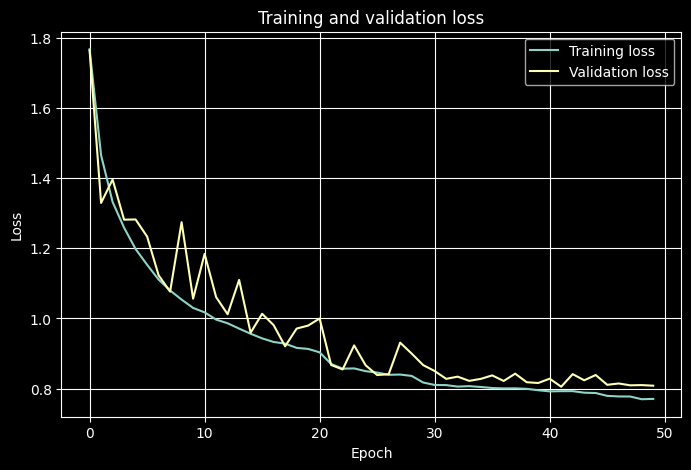

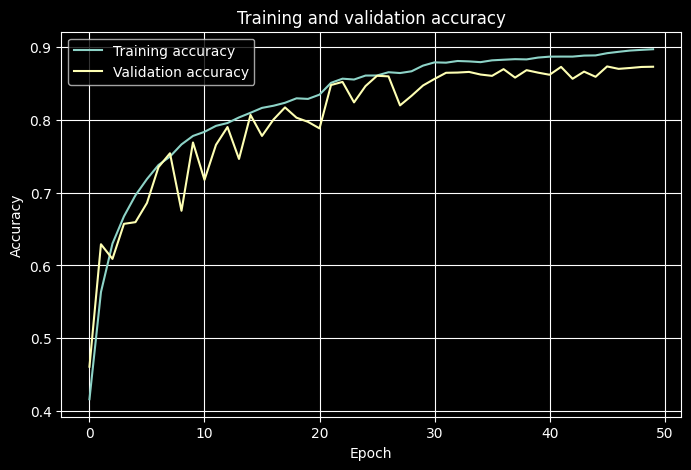

In [291]:
# Plot learning curves
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [292]:
# Evaluate on test data
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

Test loss: 0.8202
Test accuracy: 0.8669


In [293]:
# Make predictions on test set
y_prob = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

    airplane       0.89      0.85      0.87      1000
  automobile       0.92      0.94      0.93      1000
        bird       0.88      0.78      0.83      1000
         cat       0.80      0.68      0.74      1000
        deer       0.82      0.88      0.85      1000
         dog       0.81      0.82      0.81      1000
        frog       0.87      0.93      0.90      1000
       horse       0.90      0.91      0.90      1000
        ship       0.92      0.94      0.93      1000
       truck       0.86      0.94      0.90      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



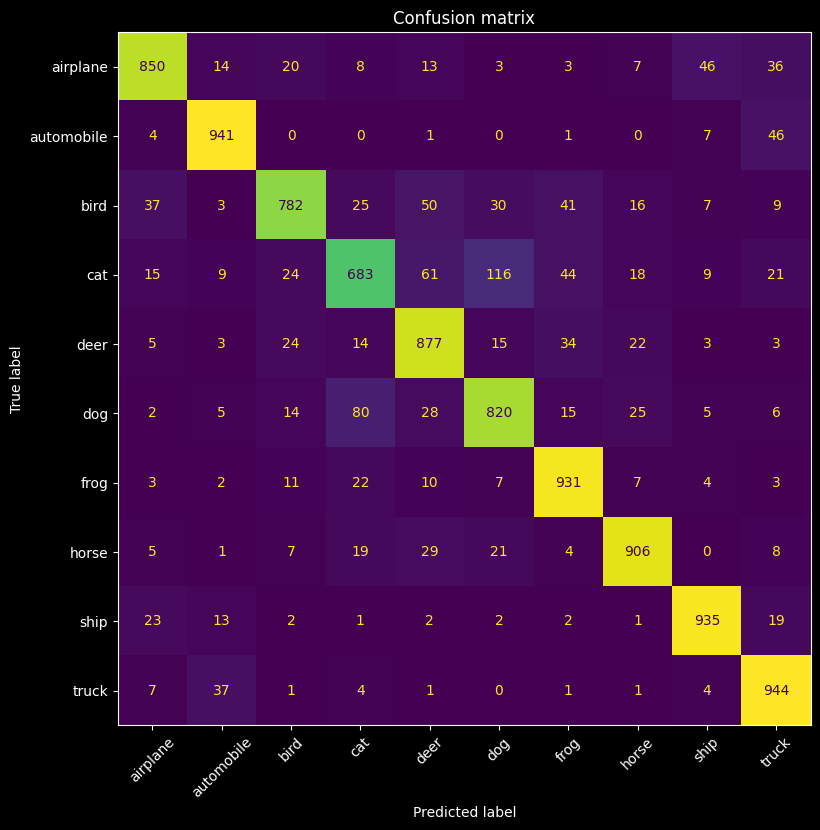

In [294]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(9, 9))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
).plot(ax=ax, xticks_rotation=45, colorbar=False)

plt.title("Confusion matrix")
plt.show()

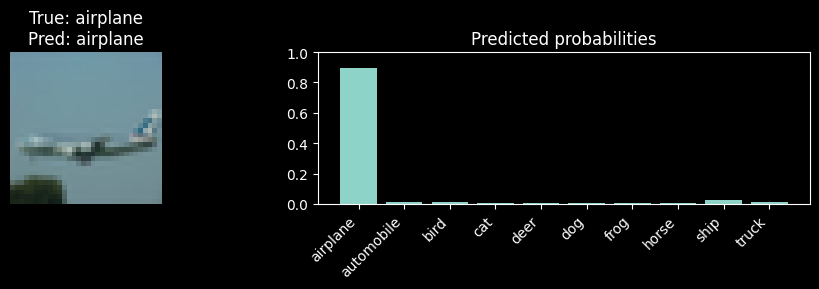

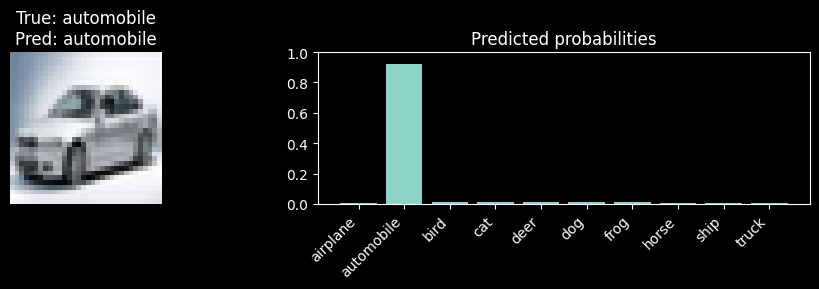

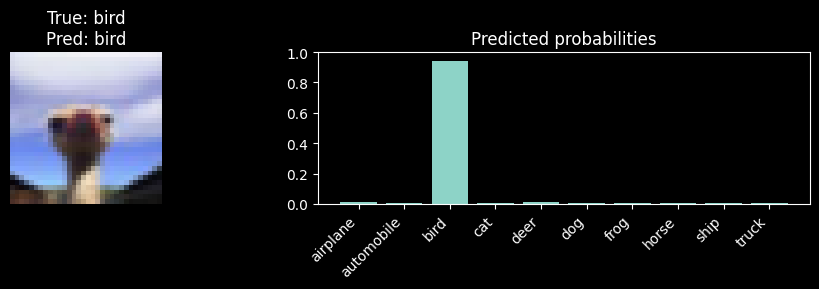

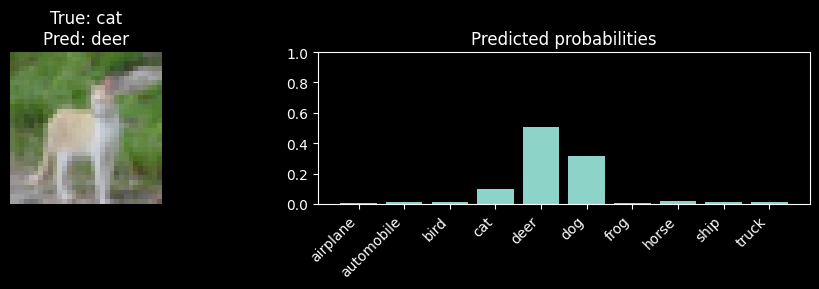

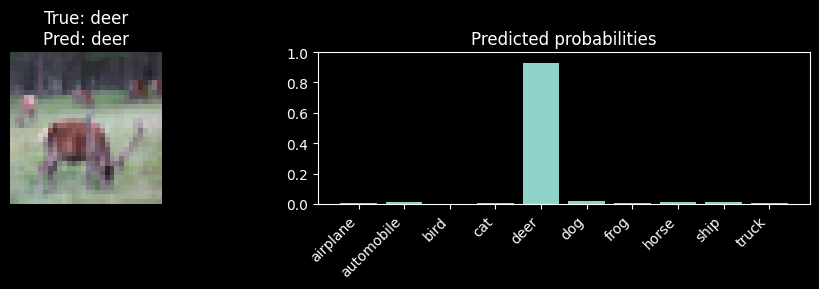

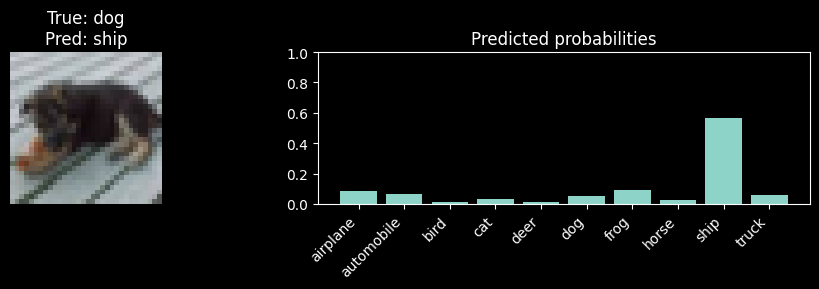

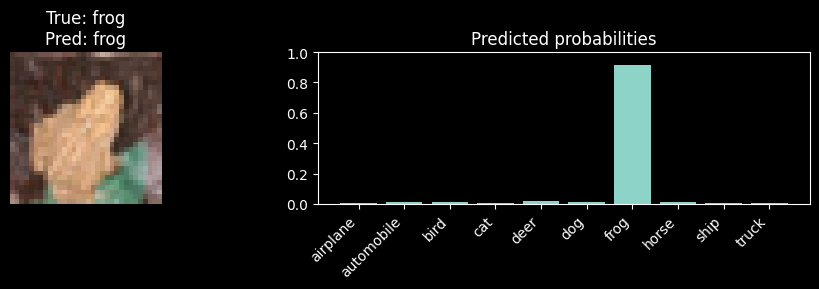

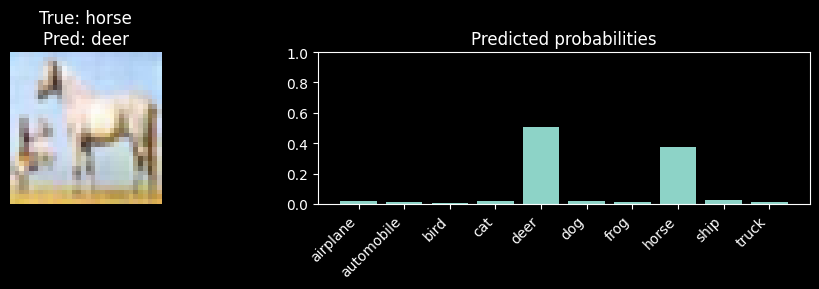

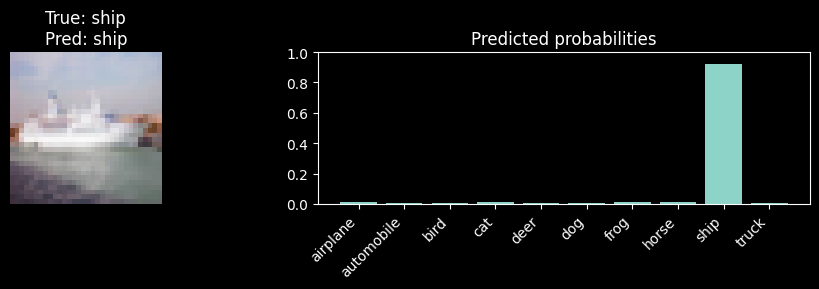

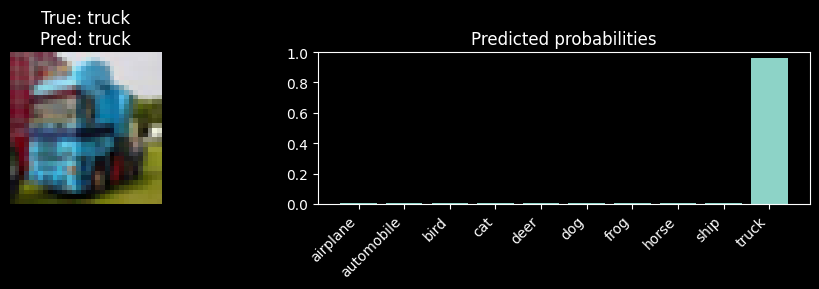

In [295]:
# Show one random example for each true label
indices = [
    np.random.choice(np.where(y_true == class_id)[0])
    for class_id in range(num_classes)
]

for idx in indices:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))

    axes[0].imshow(x_test[idx])
    axes[0].set_title(
        f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}"
    )
    axes[0].axis("off")

    axes[1].bar(range(num_classes), y_prob[idx])
    axes[1].set_xticks(range(num_classes))
    axes[1].set_xticklabels(class_names, rotation=45, ha="right")
    axes[1].set_ylim(0, 1)
    axes[1].set_title("Predicted probabilities")

    plt.tight_layout()
    plt.show()

Number of misclassified test images: 1331


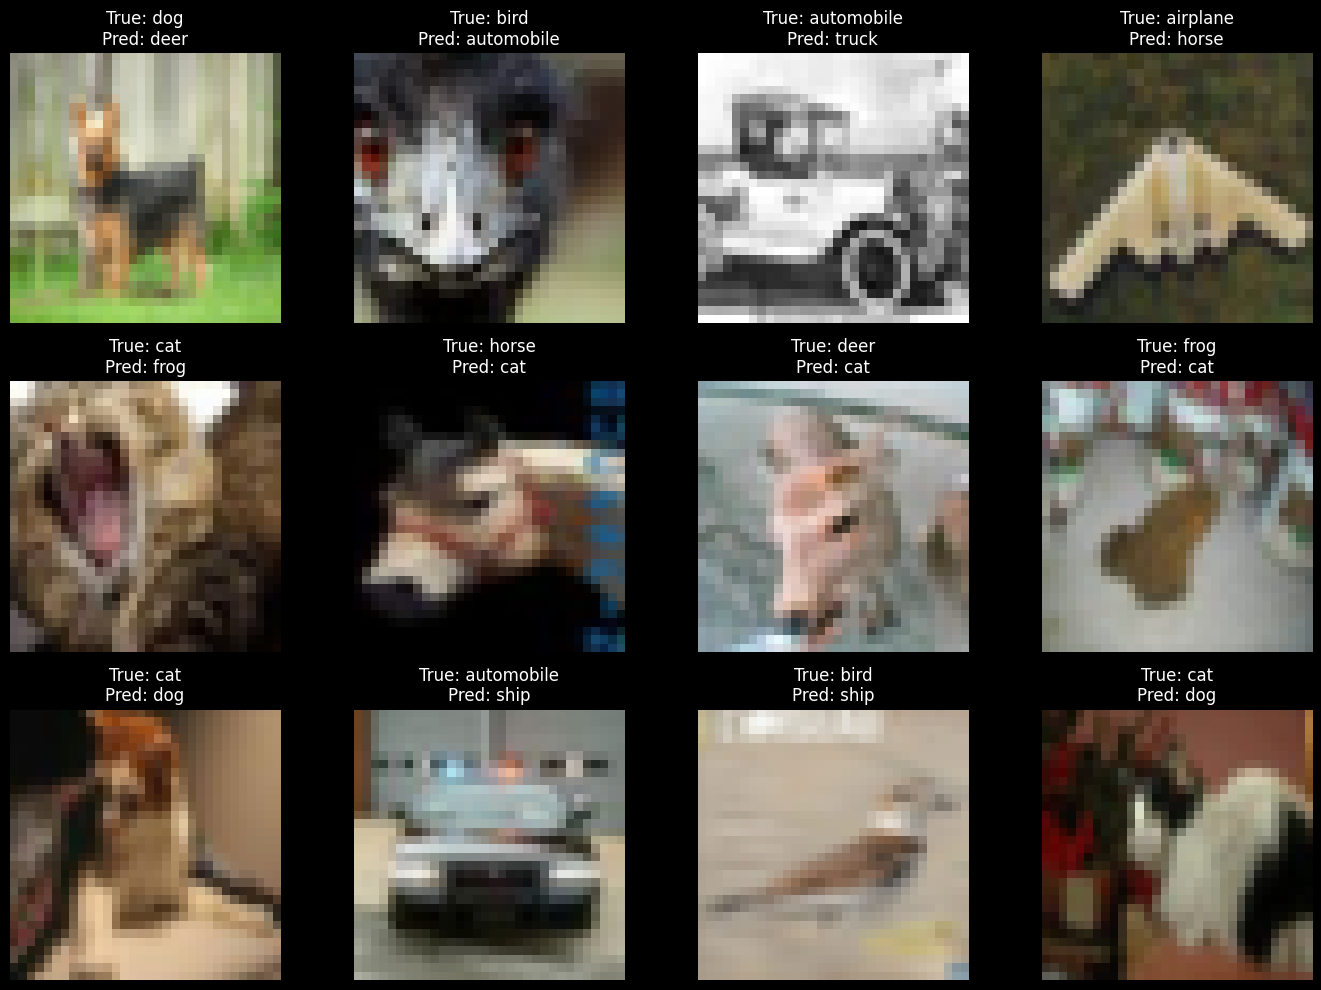

In [296]:
# Analyze misclassified images
misclassified = np.where(y_pred != y_true)[0]
print("Number of misclassified test images:", len(misclassified))

n_show = min(12, len(misclassified))
plt.figure(figsize=(14, 10))
for i, idx in enumerate(misclassified[:n_show]):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[idx])
    plt.title(
        f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}"
    )
    plt.axis("off")
plt.tight_layout()
plt.show()

## Experiement summary

In [297]:
os.makedirs("models", exist_ok=True)
model.save("models/cifar10_cnn.keras")
print("Model saved as cifar10_cnn.keras")

Model saved as cifar10_cnn.keras


In [298]:
model = keras.models.load_model("models/cifar10_cnn.keras")
print("Model loaded: cifar10_cnn")

Model loaded: cifar10_cnn
